# End-to-end text explainability

**Business context:** Product and policy teams need to see *which prompt tokens* drive a model answer before shipping FAQ bots or refund assistants. This notebook runs the full `nlp-shap` pipeline on a realistic user question, compares two generative backends on the same weights, and renders attributions for review.

**Goal:** Explain an identical snapshot with **LM Studio** (local OpenAI-compatible API) and **Hugging Face transformers**, then visualize per-token Shapley values.

**Prerequisites:** `pip install "nlp-shap[lmstudio,transformers,viz]"`, Python 3.12, LM Studio serving `qwen2-500m-instruct` (optional but recommended). Set `NLP_SHAP_E2E_MODEL` to override the default tiny HF model used for fast automated runs.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt

from nlp_shap import (
    ExplainConfig,
    ExplainRunner,
    render_attribution,
)
from nlp_shap.domain.conversation import ConversationSnapshot, Message, Turn
from nlp_shap.domain.enums import Role
from nlp_shap.masking.partitions import TokenPartitioner
from nlp_shap.pipeline.result import ExplainRunOutput


## Shared scenario


In [2]:
PROMPT = "Refund within thirty days with receipt."
LMSTUDIO_MODEL_ID = os.environ.get("NLP_SHAP_LMSTUDIO_MODEL", "qwen2-500m-instruct")
TRANSFORMERS_MODEL_ID = os.environ.get(
    "NLP_SHAP_E2E_MODEL",
    "hf-internal-testing/tiny-random-gpt2",
)
snapshot = ConversationSnapshot.from_turns((
    Turn(messages=(Message(role=Role.USER, text=PROMPT),)),
))
player_set = TokenPartitioner().partition(snapshot)
player_set.num_players


6

In [3]:
def build_config(kind: str, *, api_host: str | None = None) -> ExplainConfig:
    model_id = LMSTUDIO_MODEL_ID if kind == "lmstudio" else TRANSFORMERS_MODEL_ID
    payload = {
        "backend": {"kind": kind, "model_id": model_id, "api_host": api_host},
        "generation": {
            "max_new_tokens": 8,
            "temperature": 0.0,
            "top_k": 1,
            "precompute_base": True,
        },
        "explanation": {
            "use_v2": True,
            "estimand": "shapley",
            "estimator": "exact",
            "value_fn": "tfidf_cosine",
            "normalizer": "identity",
            "players": "tokens",
            "absence_policy": "pad",
            "budget": {"fraction": 1.0},
            "include_minimal_masks": False,
            "max_inflight": 2,
            "archive": {"path": "", "flush_every": 50},
            "dedup": {"enabled": "auto"},
            "kv_cache": {"enabled": kind == "transformers"},
            "embedding_mode": "static",
            "seed": 0,
        },
    }
    return ExplainConfig.model_validate(payload)


async def run_explain(kind: str, *, api_host: str | None = None) -> ExplainRunOutput:
    return await ExplainRunner(build_config(kind, api_host=api_host)).explain(snapshot)


## LM Studio backend


In [4]:
from nlp_shap.errors import BackendUnavailableError

lmstudio_output = None
try:
    import lmstudio as lms
except ImportError:
    print("LM Studio extra not installed — pip install 'nlp-shap[lmstudio]'.")
else:
    host = await lms.AsyncClient.find_default_local_api_host()
    if host is None or not await lms.AsyncClient.is_valid_api_host(host):
        print("LM Studio unavailable — load qwen2-500m-instruct and rerun this section.")
    else:
        try:
            lmstudio_output = await run_explain("lmstudio", api_host=host)
        except BackendUnavailableError as exc:
            print(f"LM Studio explain skipped: {exc}")
        else:
            lmstudio_output.result.values


## Transformers backend


In [5]:
transformers_output = None
try:
    transformers_output = await run_explain("transformers")
except Exception as exc:
    print(f"Transformers backend failed: {exc}")
else:
    transformers_output.result.values


Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

## Visual comparison


LM Studio SchedulerMetrics(requested=63, executed=63, deduplicated=0, cache_hits=0, kv_cache_hits=0)


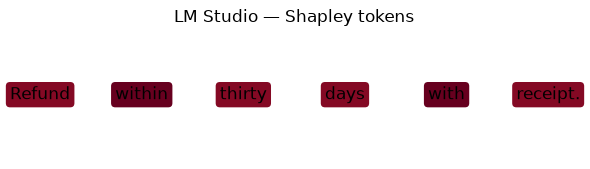

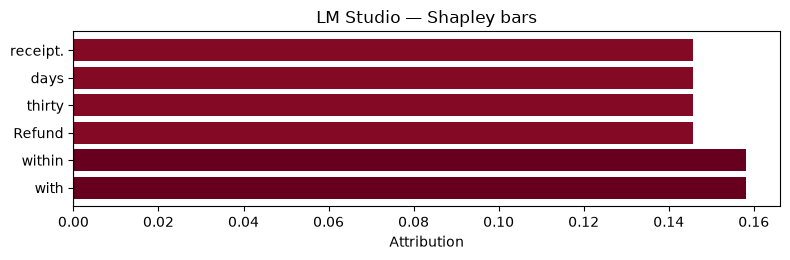

Transformers SchedulerMetrics(requested=63, executed=63, deduplicated=0, cache_hits=0, kv_cache_hits=61)


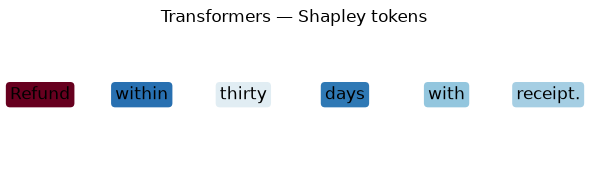

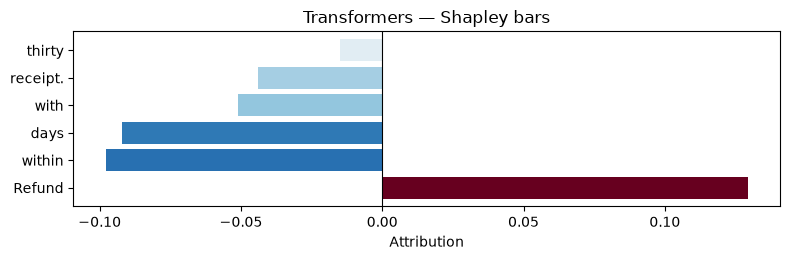

In [6]:
def visualize_run(label: str, output: ExplainRunOutput | None) -> None:
    if output is None:
        print(f"Skipping visualization for {label} — no output.")
        return
    print(label, output.metrics)
    render_attribution(
        output,
        snapshot,
        player_set,
        renderer="token_text",
        title=f"{label} — Shapley tokens",
    )
    plt.show()
    render_attribution(
        output,
        snapshot,
        player_set,
        renderer="token_bar",
        title=f"{label} — Shapley bars",
    )
    plt.show()


visualize_run("LM Studio", lmstudio_output)
visualize_run("Transformers", transformers_output)


## Optional YAML presets


In [7]:
repo_root = Path.cwd()
for name in ("dev_lmstudio.yaml", "dev_transformers.yaml"):
    path = repo_root / "config" / name
    print(name, "exists" if path.exists() else "missing")


dev_lmstudio.yaml missing
dev_transformers.yaml missing
